# Purpose:
- Generate and save cross-session normalized coding scores
- Generate and verify coding clustering using spectral clustering
- Scope: FNN sessions

In [2]:
import sys
sys.path.append('/root/capsule/code/')
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import ray

from comb.behavior_ophys_dataset import BehaviorOphysDataset, BehaviorMultiplaneOphysDataset
from comb.behavior_session_dataset import BehaviorSessionDataset
from lamf_analysis.code_ocean import capsule_bod_utils as cbu
from lamf_analysis.code_ocean import capsule_data_utils as cdu

from DesignMatrix import DesignMatrix
import load_data
import design_matrix_tools as dmtools
import kernel_tools as ktools
import glm_fit_tools as gft
import coding_score as cs
import capsule_utils as cu
import roicat_utils as rcu

# for clustering
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from scipy.cluster.hierarchy import fcluster
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
import vba_tools

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Cross-session coding score normalization
- Requires ROI matching (assume they are run and attached already)

In [3]:
mouse_ids = [717824, 721291, 736963, 739564, 747107, 755252]

## ROICat-df generation
- Updated 03/21/2025

In [25]:
glm_path = Path('/root/capsule/scratch/glm/')
for mouse_id in mouse_ids:
    roicat_df_fn = glm_path / f'roicat_df_{mouse_id}.pkl'
    if roicat_df_fn.exists():
        print(f'{roicat_df_fn} exists, skipping')
        continue
    session_info_df = cdu.get_session_info(mouse_id)
    data_dir = Path('/root/capsule/data/')
    dir_list = list(data_dir.glob(f'ROICat_cross-session-matching_{mouse_id}_*'))
    assert len(dir_list) == 1
    roicat_dir = dir_list[0]
    roicat_df = rcu.get_merged_roicat_df(session_info_df, roicat_dir)
    roicat_df.to_pickle(roicat_df_fn)

/root/capsule/scratch/glm/roicat_df_717824.pkl exists, skipping
/root/capsule/scratch/glm/roicat_df_721291.pkl exists, skipping
/root/capsule/scratch/glm/roicat_df_736963.pkl exists, skipping


100%|██████████| 8/8 [01:11<00:00,  8.90s/it]
3it [03:31, 70.39s/it]
100%|██████████| 8/8 [01:10<00:00,  8.80s/it]
3it [03:30, 70.03s/it]
100%|██████████| 8/8 [01:10<00:00,  8.80s/it]
3it [03:29, 69.78s/it]


## Coding score normalization across sessions

In [144]:
for mouse_id in mouse_ids:
    cu.calculate_and_save_cross_session_normalized_coding_score(mouse_id)

Error saving /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_717824_events.nc
Saved /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_717824_events.nc after fixing serialization issue
Error saving /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_721291_events.nc
Saved /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_721291_events.nc after fixing serialization issue
Error saving /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_736963_events.nc
Saved /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_736963_events.nc after fixing serialization issue
Error saving /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_739564_events.nc
Saved /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_739564_events.nc after fixing serialization issue
Error saving /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_747107_events.nc
Saved /root/capsule/scratch/glm/coding_score_fnn_normalized_v03_747107_events.nc after fixing serializat

# Clustering from neurons of all processed mice

### First, check if the session names are matched to known familiar, novel, and novel+1 sessions

In [152]:
mi = 5
mouse_id = mouse_ids[mi]
cs_norm_fn = glm_path / f'coding_score_fnn_normalized_v03_{mouse_id}_events.nc'
with xr.open_dataset(cs_norm_fn) as ds:
    print(ds.session.values)
session_info_df = cdu.get_session_info(mouse_id)
display(session_info_df)

['755252_2024-12-16' '755252_2024-12-17' '755252_2024-12-18']


,session_name,session_ind,session_type,raw_path,stimulus,stimulus_exposures,session_type_exposures
session_key,,,,,,,
755252_2024-12-16,multiplane-ophys_755252_2024-12-16_11-32-36,0,OPHYS_1_images_A,/root/capsule/data/multiplane-ophys_755252_202...,images_A,1,1
755252_2024-12-17,multiplane-ophys_755252_2024-12-17_08-56-37,1,OPHYS_4_images_B,/root/capsule/data/multiplane-ophys_755252_202...,images_B,1,1
755252_2024-12-18,multiplane-ophys_755252_2024-12-18_11-24-13,2,OPHYS_4_images_B,/root/capsule/data/multiplane-ophys_755252_202...,images_B,2,2


### All 6 mice confirmed
- Change session key to Familiar, Novel, Novel+1
- Concatenate them all

In [40]:
cs_norm_all = cs.concatenate_normalized_coding_scores(mouse_ids)

In [41]:
cs_norm_all.model.values

array(['all-images', 'omissions', 'task', 'behavioral'], dtype=object)

In [56]:
model_orders = ['all-images', 'omissions', 'task', 'behavioral']
session_orders = ['Familiar', 'Novel', 'Novel+1']
# sort by model_orders and then by session_orders
cs_norm_all = cs_norm_all.sortby(['model', 'experience_level'])
cs_norm_all = cs_norm_all.reindex(experience_level=session_orders, model=model_orders)

In [46]:
coding_score_novelty_df

,experience_level,model,coding_score
unique_cell_name,,,
717824_VISp_0_0006,Familiar,all-images,-0.161331
717824_VISp_0_0007,Familiar,all-images,-0.103110
717824_VISp_0_0009,Familiar,all-images,-0.198017
717824_VISp_0_0010,Familiar,all-images,-0.392726
717824_VISp_0_0011,Familiar,all-images,-0.182997
...,...,...,...
755252_VISp_7_0070,Novel+1,behavioral,-0.392548
755252_VISp_7_0071,Novel+1,behavioral,-0.195580
755252_VISp_7_0072,Novel+1,behavioral,-0.093889


In [50]:
feature_table = coding_score_novelty_df.pivot(columns=(
                    'model', 'experience_level'))
# feature_table = feature_table.swaplevel(axis=1)
feature_table

coding_score                                            \
model                all-images omissions      task behavioral all-images   
experience_level       Familiar  Familiar  Familiar   Familiar      Novel   
unique_cell_name                                                            
717824_VISp_0_0006    -0.161331 -0.086093 -0.146134  -0.254122  -0.146380   
717824_VISp_0_0007    -0.103110 -0.100348 -0.029323  -0.219968  -0.151608   
717824_VISp_0_0009    -0.198017 -0.036747 -0.073232  -0.718921  -0.204714   
717824_VISp_0_0010    -0.392726 -0.021677 -0.194409  -0.064358  -0.607275   
717824_VISp_0_0011    -0.182997 -0.026213 -0.108182  -0.452004  -0.267003   
...                         ...       ...       ...        ...        ...   
755252_VISp_7_0070    -0.169602 -0.050970 -0.081441  -0.729203  -0.205353   
755252_VISp_7_0071    -0.524483 -0.022918 -0.121772  -0.416279  -0.365559   
755252_VISp_7_0072    -0.357810 -0.094819 -0.225885  -0.298594  -0.557978   
755252_VISp_7_0073    -0.258028 -0.032536 -0.061357  -0.740783  -0.118120   
755252_VISp_7_0075    -0.305874 -0.040174 -0.079731  -0.427455  -0.353324   

                                                                        \
model              omissions      task behavioral all-images omissions   
experience_level       Novel     Novel      Novel    Novel+1   Novel+1   
unique_cell_name                                                         
717824_VISp_0_0006 -0.102064 -0.229685  -0.424875  -0.129589 -0.109155   
717824_VISp_0_0007 -0.109441 -0.297850  -0.344554  -0.086163 -0.123639   
717824_VISp_0_0009 -0.109798 -0.158321  -0.593981  -0.108310 -0.148132   
717824_VISp_0_0010 -0.020523 -0.129849  -0.041271  -0.753262 -0.059000   
717824_VISp_0_0011 -0.081769 -0.083765  -0.552065  -0.096378 -0.156492   
...                      ...       ...        ...        ...       ...   
755252_VISp_7_0070 -0.082986 -0.056195  -0.432514  -0.190731 -0.088214   
755252_VISp_7_0071 -0.026042 -0.089169  -0.306113  -0.141797 -0.012026   
755252_VISp_7_0072 -0.061201 -0.123004  -0.229436  -0.452692 -0.078266   
755252_VISp_7_0073 -0.030281 -0.028443  -0.502859  -0.114621 -0.046654   
755252_VISp_7_0075 -0.032885 -0.058725  -0.375144  -0.377324 -0.037866   

                                         
model                   task behavioral  
experience_level     Novel+1    Novel+1  
unique_cell_name                         
717824_VISp_0_0006 -0.053440  -0.630710  
717824_VISp_0_0007 -0.051165  -0.493483  
717824_VISp_0_0009 -0.132969  -0.756965  
717824_VISp_0_0010 -0.098073  -0.029892  
717824_VISp_0_0011 -0.058049  -0.879155  
...                      ...        ...  
755252_VISp_7_0070 -0.069515  -0.392548  
755252_VISp_7_0071 -0.108938  -0.195580  
755252_VISp_7_0072 -0.112245  -0.093889  
755252_VISp_7_0073 -0.055608  -0.407586  
755252_VISp_7_0075 -0.067175  -0.325640  

[1918 rows x 12 columns]

In [63]:
coding_score_novelty_df = cs_norm_all.to_dataframe(
                            name='coding_score', dim_order=['unique_cell_name', 'model', 'experience_level']).reset_index(
                            ).set_index('unique_cell_name', 
                            drop=True)
coding_score_novelty_df 

,model,experience_level,coding_score
unique_cell_name,,,
717824_VISp_0_0006,all-images,Familiar,-0.161331
717824_VISp_0_0006,all-images,Novel,-0.146380
717824_VISp_0_0006,all-images,Novel+1,-0.129589
717824_VISp_0_0006,omissions,Familiar,-0.086093
717824_VISp_0_0006,omissions,Novel,-0.102064
...,...,...,...
755252_VISp_7_0075,task,Novel,-0.058725
755252_VISp_7_0075,task,Novel+1,-0.067175
755252_VISp_7_0075,behavioral,Familiar,-0.427455


In [66]:
models = cs_norm_all.model.values
coding_score_novelty_df = cs_norm_all.to_dataframe(
                            name='coding_score',
                            dim_order=['unique_cell_name', 'model', 'experience_level']).reset_index(
                            ).set_index('unique_cell_name', 
                            drop=True)
feature_table = coding_score_novelty_df.pivot(columns=(
                    'model', 'experience_level'))
feature_table.columns = feature_table.columns.droplevel(0)
feature_table = feature_table.rename(columns={'all-images': 'Images', 
                              'omissions': 'Omissions',
                              'task': 'Task',
                              'behavioral': 'Behavior'})

In [67]:
feature_table

model                 Images                     Omissions            \
experience_level    Familiar     Novel   Novel+1  Familiar     Novel   
unique_cell_name                                                       
717824_VISp_0_0006 -0.161331 -0.146380 -0.129589 -0.086093 -0.102064   
717824_VISp_0_0007 -0.103110 -0.151608 -0.086163 -0.100348 -0.109441   
717824_VISp_0_0009 -0.198017 -0.204714 -0.108310 -0.036747 -0.109798   
717824_VISp_0_0010 -0.392726 -0.607275 -0.753262 -0.021677 -0.020523   
717824_VISp_0_0011 -0.182997 -0.267003 -0.096378 -0.026213 -0.081769   
...                      ...       ...       ...       ...       ...   
755252_VISp_7_0070 -0.169602 -0.205353 -0.190731 -0.050970 -0.082986   
755252_VISp_7_0071 -0.524483 -0.365559 -0.141797 -0.022918 -0.026042   
755252_VISp_7_0072 -0.357810 -0.557978 -0.452692 -0.094819 -0.061201   
755252_VISp_7_0073 -0.258028 -0.118120 -0.114621 -0.032536 -0.030281   
755252_VISp_7_0075 -0.305874 -0.353324 -0.377324 -0.040174 -0.032885   

model                             Task                      Behavior  \
experience_level     Novel+1  Familiar     Novel   Novel+1  Familiar   
unique_cell_name                                                       
717824_VISp_0_0006 -0.109155 -0.146134 -0.229685 -0.053440 -0.254122   
717824_VISp_0_0007 -0.123639 -0.029323 -0.297850 -0.051165 -0.219968   
717824_VISp_0_0009 -0.148132 -0.073232 -0.158321 -0.132969 -0.718921   
717824_VISp_0_0010 -0.059000 -0.194409 -0.129849 -0.098073 -0.064358   
717824_VISp_0_0011 -0.156492 -0.108182 -0.083765 -0.058049 -0.452004   
...                      ...       ...       ...       ...       ...   
755252_VISp_7_0070 -0.088214 -0.081441 -0.056195 -0.069515 -0.729203   
755252_VISp_7_0071 -0.012026 -0.121772 -0.089169 -0.108938 -0.416279   
755252_VISp_7_0072 -0.078266 -0.225885 -0.123004 -0.112245 -0.298594   
755252_VISp_7_0073 -0.046654 -0.061357 -0.028443 -0.055608 -0.740783   
755252_VISp_7_0075 -0.037866 -0.079731 -0.058725 -0.067175 -0.427455   

model                                   
experience_level       Novel   Novel+1  
unique_cell_name                        
717824_VISp_0_0006 -0.424875 -0.630710  
717824_VISp_0_0007 -0.344554 -0.493483  
717824_VISp_0_0009 -0.593981 -0.756965  
717824_VISp_0_0010 -0.041271 -0.029892  
717824_VISp_0_0011 -0.552065 -0.879155  
...                      ...       ...  
755252_VISp_7_0070 -0.432514 -0.392548  
755252_VISp_7_0071 -0.306113 -0.195580  
755252_VISp_7_0072 -0.229436 -0.093889  
755252_VISp_7_0073 -0.502859 -0.407586  
755252_VISp_7_0075 -0.375144 -0.325640  

[1918 rows x 12 columns]

In [68]:
# save the table
coding_score_table_fn = glm_path / f'fnn_coding_score_table_glm_v03.pkl'
feature_table.to_pickle(coding_score_table_fn)

In [4]:
# Loading the data
glm_path = Path('/root/capsule/scratch/glm/')
coding_score_table_fn = glm_path / f'fnn_coding_score_table_glm_v03.pkl'
feature_table = pd.read_pickle(coding_score_table_fn)

## Data exploration
- Mouse-to-mouse variation

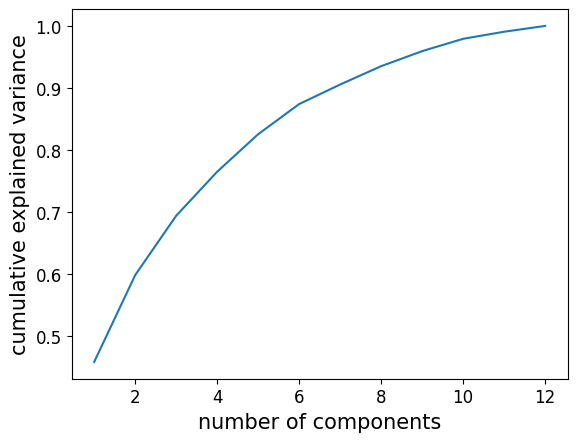

In [69]:
# PCA

pca = PCA()
pca.fit(feature_table.values)
# show the results
fig, ax = plt.subplots()
ax.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('number of components', fontsize=15)
ax.set_ylabel('cumulative explained variance', fontsize=15)
ax.tick_params(axis='both', labelsize=12)

Text(0, 0.5, 'PC 2')

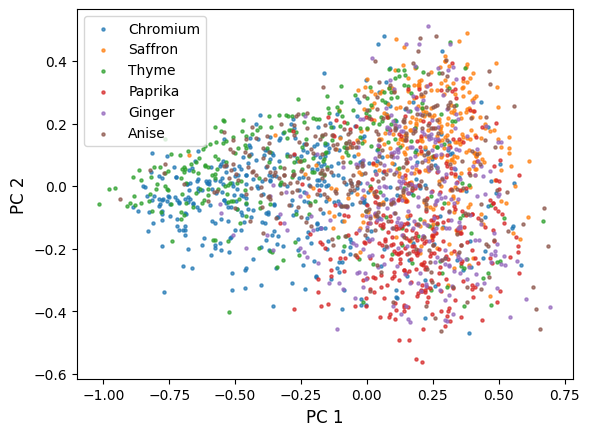

In [245]:
# show embedding
# See if there's any weird relationship with mouse
pcs = [1,2]

feature_table_with_info = feature_table.copy()
feature_table_with_info['mouse_id'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[0]))

fig, ax = plt.subplots()
feature_table_pca = pca.transform(feature_table.values)
cmap = plt.get_cmap('tab10')
for mi, mouse_id in enumerate(mouse_ids):
    cell_inds = np.where(feature_table_with_info['mouse_id'] == mouse_id)[0]
    mouse_name = cu.ID_NAME_MAP[mouse_id]
    ax.scatter(feature_table_pca[cell_inds[0], pcs[0]-1], feature_table_pca[cell_inds[0], pcs[1]-1],
               label=mouse_name, color=cmap(mi), alpha=0.7, s=5)    
    ax.scatter(feature_table_pca[cell_inds, pcs[0]-1], feature_table_pca[cell_inds, pcs[1]-1],
               color=cmap(mi), alpha=0.7, s=5)
ax.legend()
ax.set_xlabel(f'PC {pcs[0]}', fontsize=12)
ax.set_ylabel(f'PC {pcs[1]}', fontsize=12)




Text(0, 0.5, 'PC 4')

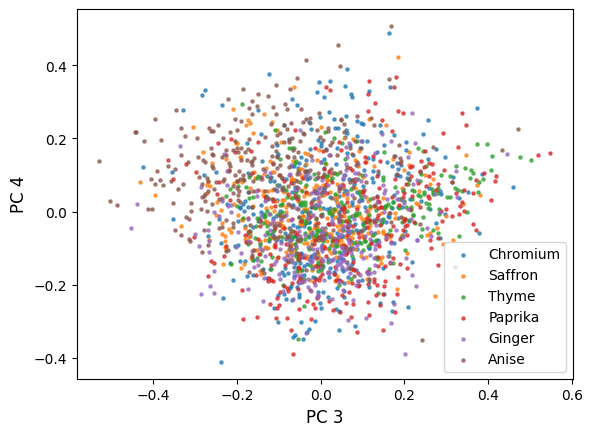

In [246]:
pcs = [3,4]

feature_table_with_info = feature_table.copy()
feature_table_with_info['mouse_id'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[0]))

fig, ax = plt.subplots()
feature_table_pca = pca.transform(feature_table.values)
cmap = plt.get_cmap('tab10')
for mi, mouse_id in enumerate(mouse_ids):
    cell_inds = np.where(feature_table_with_info['mouse_id'] == mouse_id)[0]
    mouse_name = cu.ID_NAME_MAP[mouse_id]
    ax.scatter(feature_table_pca[cell_inds[0], pcs[0]-1], feature_table_pca[cell_inds[0], pcs[1]-1],
               label=mouse_name, color=cmap(mi), alpha=0.7, s=5)    
    ax.scatter(feature_table_pca[cell_inds, pcs[0]-1], feature_table_pca[cell_inds, pcs[1]-1],
               color=cmap(mi), alpha=0.7, s=5)
ax.legend()
ax.set_xlabel(f'PC {pcs[0]}', fontsize=12)
ax.set_ylabel(f'PC {pcs[1]}', fontsize=12)


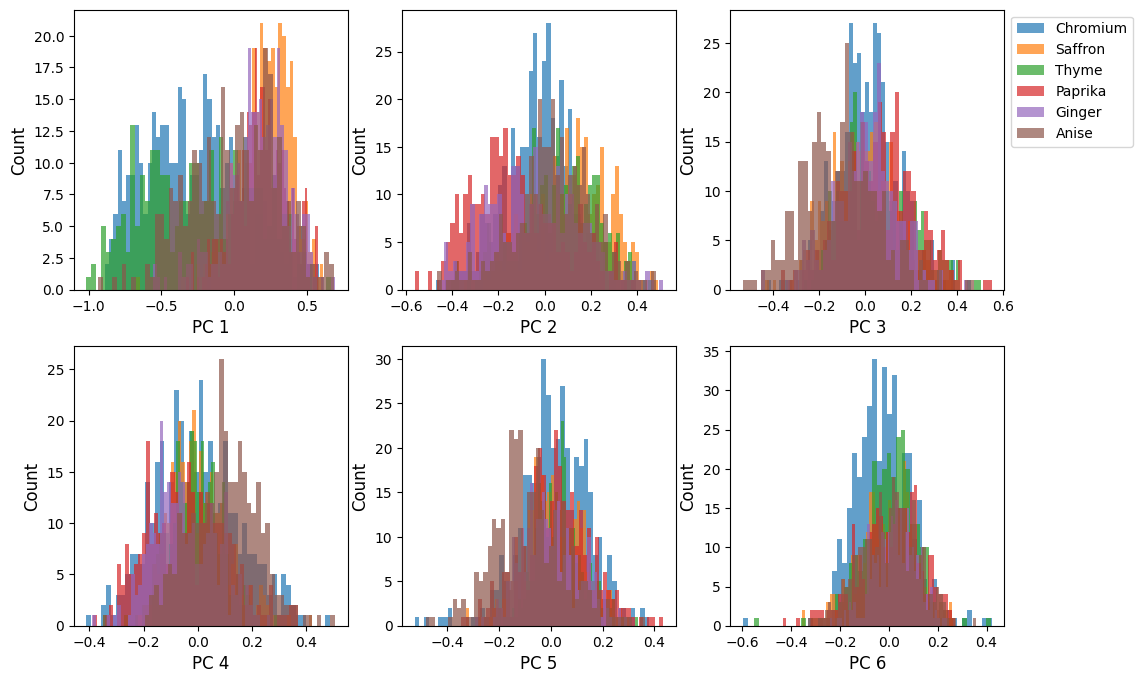

In [247]:
# plot distribution across mice for each PC projection
pcs = np.arange(1,7)
fig, axs = plt.subplots(2,3, figsize=(12,8))
axs = axs.flatten()
feature_table_with_info = feature_table.copy()
feature_table_with_info['mouse_id'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[0]))
for pi, pc in enumerate(pcs):
    ax = axs[pi]
    for mi, mouse_id in enumerate(mouse_ids):
        mouse_name = cu.ID_NAME_MAP[mouse_id]
        cell_inds = np.where(feature_table_with_info['mouse_id'] == mouse_id)[0]
        ax.hist(feature_table_pca[cell_inds, pc-1], bins=50, alpha=0.7, label=mouse_name)
    ax.set_xlabel(f'PC {pc}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    if pi == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1,1))

In [270]:
# measure pairwise distance between all cells
# group them by mouse_id
feature_table_with_info = feature_table.copy()
feature_table_with_info['mouse_id'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[0]))
mouse_ids = feature_table_with_info['mouse_id'].unique()

# check if the table is sorted by mouse_id
for mouse_id in mouse_ids:
    unique_diff_i = np.unique(np.diff(np.where(feature_table_with_info['mouse_id'] == mouse_id)[0]))
    assert len(unique_diff_i) == 1
    assert unique_diff_i[0] == 1

# calculate normalized distance matrix using pdist
distances = pdist(feature_table.values, metric='euclidean')
distances = distances / np.max(distances)
dist_matrix = squareform(distances)



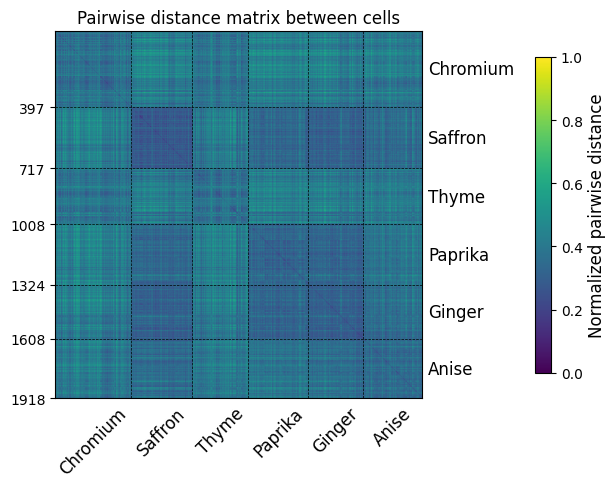

In [293]:
fig, ax = plt.subplots()
im = ax.imshow(dist_matrix)
cbar= plt.colorbar(im, ax=ax, label='Normalized pairwise distance', shrink=0.8, pad=0.2)
cbar.set_label('Normalized pairwise distance', fontsize=12)

num_cell_per_mouse = [np.sum(feature_table_with_info['mouse_id'] == mouse_id) for mouse_id in mouse_ids]
cum_num_cell_per_mouse = np.cumsum(num_cell_per_mouse)
num_cell_all = len(feature_table)
for cum_num in cum_num_cell_per_mouse[:-1]:
    ax.axhline(cum_num-1, color='k', linewidth=0.5, linestyle='--')
    ax.axvline(cum_num-1, color='k', linewidth=0.5, linestyle='--')
ax.set_xticks([])
ax.set_yticks(cum_num_cell_per_mouse-1);
ax.set_yticklabels(cum_num_cell_per_mouse)
ax.set_xlim([0, len(feature_table)])
ax.set_ylim([len(feature_table)-1, 0])
# put label of mouse_id at the center of each cum_num_cell_per_mouse on the right side of the matrix
for mi, mouse_id in enumerate(mouse_ids):
    mouse_name = cu.ID_NAME_MAP[mouse_id]
    ax.text(num_cell_all + 30, cum_num_cell_per_mouse[mi]-num_cell_per_mouse[mi]//2,  
            mouse_name, fontsize=12, ha='left', va='center')
    ax.text(cum_num_cell_per_mouse[mi]-num_cell_per_mouse[mi]//2, num_cell_all + 30,
            mouse_name, fontsize=12, ha='center', va='top', rotation=45)
ax.set_title('Pairwise distance matrix between cells')

fig.tight_layout()


Text(0.5, 1.0, 'Mean distance between cells\nwithin and between mice')

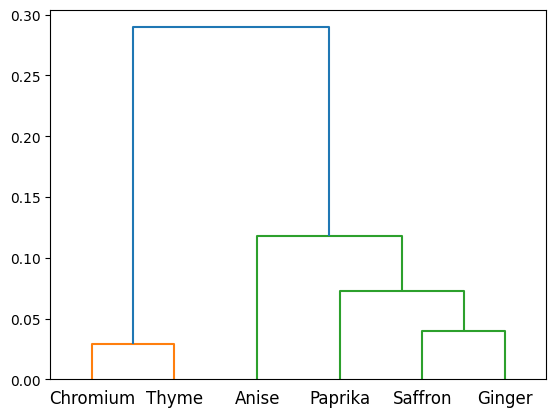

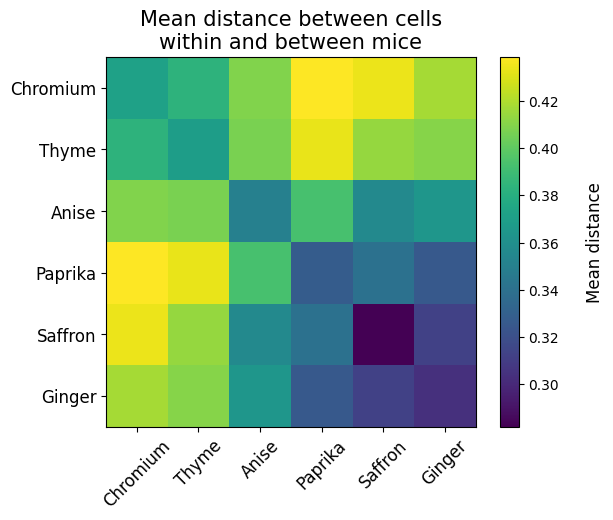

In [280]:
# calculate the mean distance between cells within the same mouse and between different mice
mean_dist_matrix = np.zeros((len(mouse_ids), len(mouse_ids)))
for mi1, mouse_id1 in enumerate(mouse_ids):
    for mi2, mouse_id2 in enumerate(mouse_ids):
        cell_inds1 = np.where(feature_table_with_info['mouse_id'] == mouse_id1)[0]
        cell_inds2 = np.where(feature_table_with_info['mouse_id'] == mouse_id2)[0]
        mean_dist_matrix[mi1, mi2] = np.mean(dist_matrix[np.ix_(cell_inds1, cell_inds2)])
# cluster the mean distance matrix
linkage = sch.linkage(mean_dist_matrix, method='ward')
dendrogram = sch.dendrogram(linkage, labels=[cu.ID_NAME_MAP[mid] for mid in mouse_ids])
# reorder the mean_dist_matrix
reorder_inds = dendrogram['leaves']
fig, ax = plt.subplots()
im = ax.imshow(mean_dist_matrix[reorder_inds, :][:, reorder_inds])
ax.set_xticks(range(len(mouse_ids)))
ax.set_yticks(range(len(mouse_ids)))
label_order = np.array([cu.ID_NAME_MAP[mid] for mid in mouse_ids])
label_order = label_order[reorder_inds]

ax.set_xticklabels(label_order, rotation=45, fontsize=12)
ax.set_yticklabels(label_order, fontsize=12);

# add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('\nMean distance', fontsize=12)
ax.set_title('Mean distance between cells\nwithin and between mice', fontsize=15)

It can be due to running (Based on session QC plots)  
Check their average run distance
- Checked visually with mouse QC and the results are aligned

In [323]:
session_key_list = []
run_distance_list = []
for mouse_id in mouse_ids:
    cs_norm_fn = glm_path / f'coding_score_fnn_normalized_v03_{mouse_id}_events.nc'
    with xr.open_dataset(cs_norm_fn) as ds:
        session_keys = ds.session.values
    session_info_df = cdu.get_session_info(mouse_id)
    fnn_info = session_info_df.loc[session_keys]
    for session_key, row in fnn_info.iterrows():
        raw_path = Path(row['raw_path'])
        bod = cdu.get_any_bod(raw_path)
        running_df = bod.running_speed
        run_distance = (running_df.timestamps.diff() * running_df.speed
                        ).sum() /100 # in meters
        session_key_list.append(session_key)
        run_distance_list.append(run_distance)
run_distance_df = pd.DataFrame({'session_key': session_key_list,
                                'run_distance': run_distance_list}
                                ).set_index('session_key')


In [327]:
run_distance_df['mouse_id'] = run_distance_df.apply(lambda x: int(x.name.split('_')[0]), axis=1)
mean_run_distance_df = run_distance_df.groupby('mouse_id').mean()
mean_run_distance_df['mouse_name'] = mean_run_distance_df.index.map(lambda x: cu.ID_NAME_MAP[x])
mean_run_distance_df

,run_distance,mouse_name
mouse_id,,
717824,0.169170,Chromium
721291,1617.089597,Saffron
736963,41.020976,Thyme
739564,1657.823715,Paprika
747107,1845.371317,Ginger
755252,81.896029,Anise


In [340]:
mean_run_distance_df.sort_values('run_distance')

,run_distance,mouse_name
mouse_id,,
717824,0.169170,Chromium
736963,41.020976,Thyme
755252,81.896029,Anise
721291,1617.089597,Saffron
739564,1657.823715,Paprika
747107,1845.371317,Ginger


What about z-drift?

Umap

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


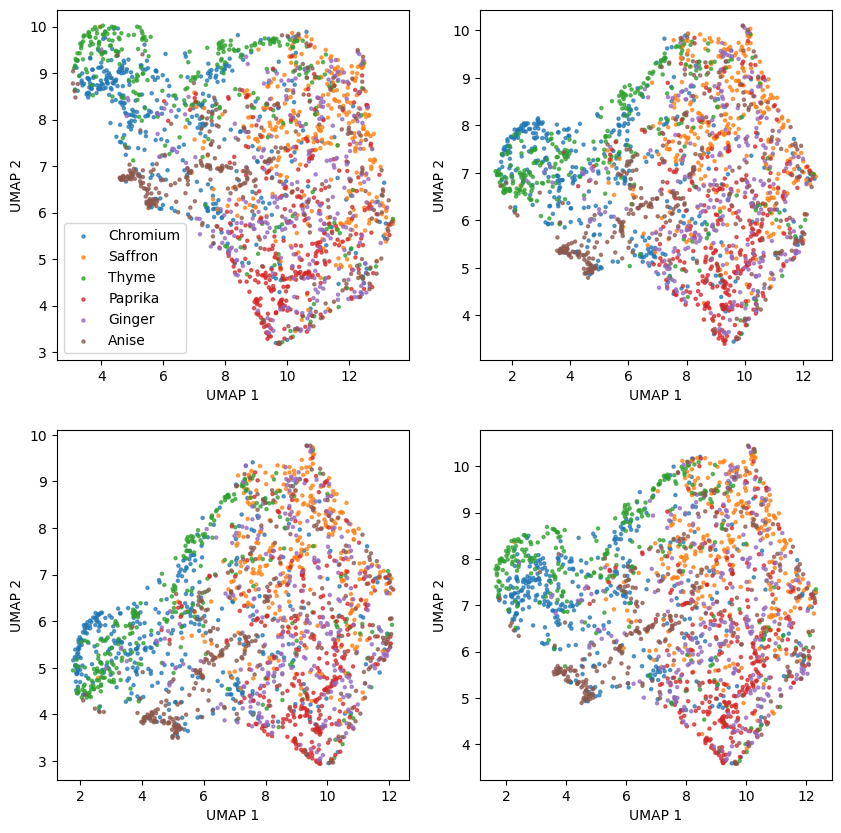

In [339]:
# show feature_table data in UMAP
cmap = plt.get_cmap('tab10')
mouse_ids = np.sort(feature_table_with_info['mouse_id'].unique())
feature_table_with_info['mouse_ind'] = feature_table_with_info['mouse_id'].map(lambda x: np.where(mouse_ids == x)[0][0])
fig, ax = plt.subplots(2,2, figsize=(10,10))
for i in range(4):
    ix, iy = i//2, i%2
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(feature_table.values)

    for mi, mouse_id in enumerate(mouse_ids):
        cell_inds = np.where(feature_table_with_info['mouse_id'] == mouse_id)[0]
        mouse_name = cu.ID_NAME_MAP[mouse_id]
        ax[iy, ix].scatter(embedding[cell_inds[0], 0], embedding[cell_inds[0], 1],
                label=mouse_name, color=cmap(mi), alpha=0.7, s=5)
    if i == 0:
        ax[iy, ix].legend()

    ax[iy, ix].scatter(embedding[:, 0], embedding[:, 1], c=cmap(feature_table_with_info['mouse_ind'].values),
                       s=5, alpha=0.7)
    ax[iy, ix].set_xlabel('UMAP 1')
    ax[iy, ix].set_ylabel('UMAP 2')


# Clustering

In [341]:
# hierarchical clustering
k_max = 30
shuffle_type = 'all'
metric = 'euclidean'

hc = AgglomerativeClustering()
gap_df_hc = vba_tools.compute_gap(clustering=hc, data=feature_table, k_max=k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

Reference inertia for 1 clusters
Reference inertia for 2 clusters
Reference inertia for 3 clusters
Reference inertia for 4 clusters
Reference inertia for 5 clusters
Reference inertia for 6 clusters
Reference inertia for 7 clusters
Reference inertia for 8 clusters
Reference inertia for 9 clusters
Reference inertia for 10 clusters
Reference inertia for 11 clusters
Reference inertia for 12 clusters
Reference inertia for 13 clusters
Reference inertia for 14 clusters
Reference inertia for 15 clusters
Reference inertia for 16 clusters
Reference inertia for 17 clusters
Reference inertia for 18 clusters
Reference inertia for 19 clusters
Reference inertia for 20 clusters
Reference inertia for 21 clusters
Reference inertia for 22 clusters
Reference inertia for 23 clusters
Reference inertia for 24 clusters
Reference inertia for 25 clusters
Reference inertia for 26 clusters
Reference inertia for 27 clusters
Reference inertia for 28 clusters
Reference inertia for 29 clusters
On data inertia for 1 c

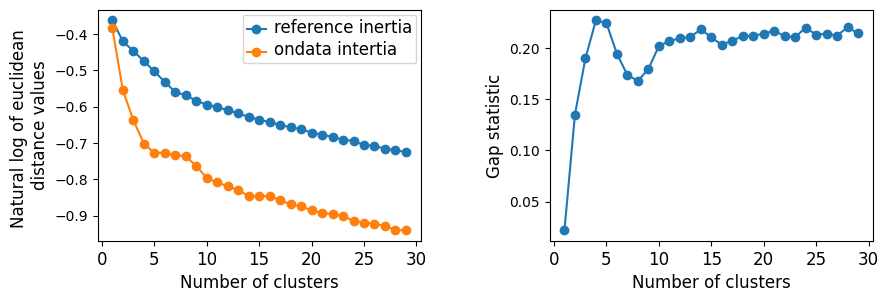

In [342]:
ax = vba_tools.plot_gap_statistic(gap_df_hc)
for axx in ax:
    axx.set_xlabel(axx.get_xlabel(), fontsize=12)
    axx.set_ylabel(axx.get_ylabel(), fontsize=12)
    axx.set_xticks(np.arange(0, k_max+1, 5))
    axx.set_xticklabels(np.arange(0, k_max+1, 5), fontsize=12)
    leg = axx.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(12)

/opt/conda/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


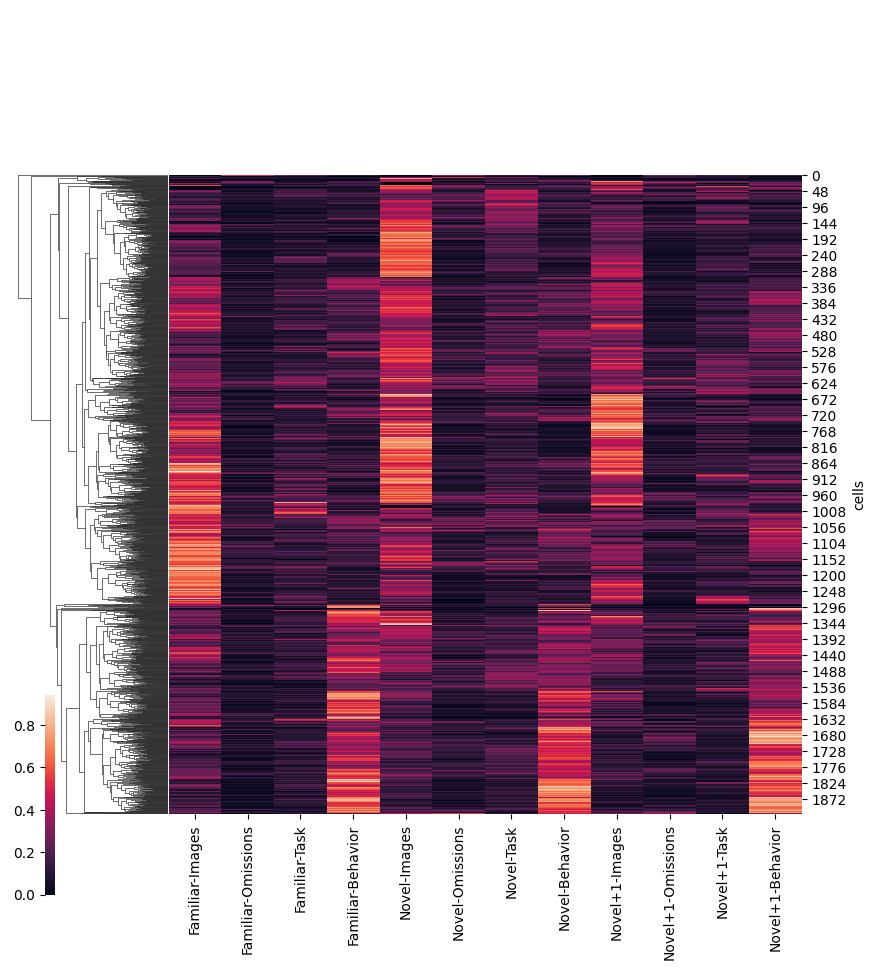

In [345]:
g = sns.clustermap(-feature_table, row_cluster=True, col_cluster=False, 
                   method='average',
                   cbar_pos=(0.05, 0.1, 0.01, 0.2))
ax = g.ax_heatmap
ytick_positions = g.ax_heatmap.get_yticks()
ax.set_yticklabels([int(y) for y in ytick_positions]);
ax.set_ylabel('cells')
ax.set_xlabel('')
g.cax.yaxis.set_ticks_position('left')


In [70]:
# Spectral clustering parameters
dm_version = 3
data_type = 'events'
suffix = ''

metric = 'euclidean' # default distance metric
shuffle_type ='all' # default shuffle type is all shuffle (cell id and regressors)
k_max = 30 #max number of clusters to test

sc = SpectralClustering()
gap_df = vba_tools.compute_gap(clustering=sc, data=feature_table, k_max=k_max, 
                               reference_shuffle=shuffle_type, metric=metric, parallel=True)

gap_save_fn = glm_path / f'clustering/gap_{dm_version:02}_{data_type}{suffix}.npy'
gap_save_fn.parent.mkdir(parents=True, exist_ok=True)
np.save(gap_save_fn, gap_df)

2025-03-14 07:14:40,499	INFO worker.py:1841 -- Started a local Ray instance.
2025-03-14 07:14:41,843	INFO packaging.py:575 -- Creating a file package for local module '/root/capsule/code'.
2025-03-14 07:14:43,675	INFO packaging.py:367 -- Pushing file package 'gcs://_ray_pkg_efb25562edaeec1a.zip' (46.88MiB) to Ray cluster...
2025-03-14 07:14:43,779	INFO packaging.py:380 -- Successfully pushed file package 'gcs://_ray_pkg_efb25562edaeec1a.zip'.


Reference inertia for 1 clusters


KeyboardInterrupt: 

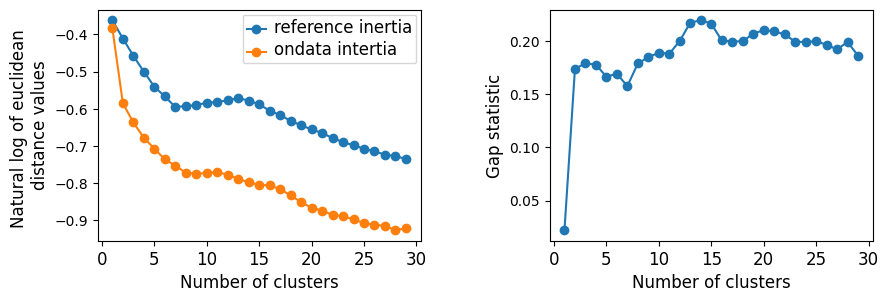

In [378]:
ax = vba_tools.plot_gap_statistic(gap_df)
for axx in ax:
    axx.set_xlabel(axx.get_xlabel(), fontsize=12)
    axx.set_ylabel(axx.get_ylabel(), fontsize=12)
    axx.set_xticks(np.arange(0, k_max+1, 5))
    axx.set_xticklabels(np.arange(0, k_max+1, 5), fontsize=12)
    leg = axx.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(12)

In [32]:
metric = 'euclidean' # default distance metric
shuffle_type ='all' # default shuffle type is all shuffle (cell id and regressors)
k_max = 30 #max number of clusters to test

sc = SpectralClustering()
sc.fit(feature_table.values)
A = sc.affinity_matrix_
eigenvalues, eigenvectors, nb_clusters = vba_tools.get_eigenDecomposition(A, max_n_clusters=k_max)

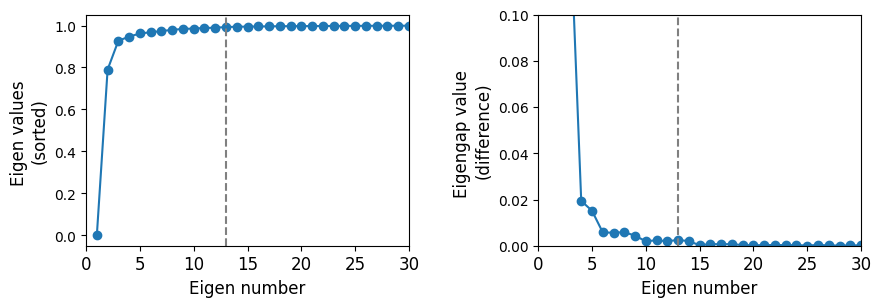

In [33]:
ax = vba_tools.plot_eigengap_values(eigenvalues, n_clusters=13)
for axx in ax:
    axx.set_xlabel(axx.get_xlabel(), fontsize=12)
    axx.set_ylabel(axx.get_ylabel(), fontsize=12)
    axx.set_xticks(np.arange(0, k_max+1, 5))
    axx.set_xticklabels(np.arange(0, k_max+1, 5), fontsize=12)
    leg = axx.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(12)

In [384]:
# Silhouette Score
n_clusters = np.arange(2, k_max)
n_boots = 20
silhouette_scores, silhouette_std = vba_tools.get_silhouette_scores(
    X=feature_table.values, model=SpectralClustering(), n_clusters=n_clusters, metric=metric, n_boots=n_boots)

2025-03-14 03:53:03,210	INFO worker.py:1672 -- Calling ray.init() again after it has already been called.


size of X = (1918, 12)
NaNs in the array = 0
n 2 clusters mean score = 0.30822870402898495
n 3 clusters mean score = 0.20262877254927508
n 4 clusters mean score = 0.1778732791375189
n 5 clusters mean score = 0.15602170859567296
n 6 clusters mean score = 0.14576604277361632
n 7 clusters mean score = 0.13467936543474085
n 8 clusters mean score = 0.12658020297248768
n 9 clusters mean score = 0.11549315279469904
(autoscaler +81h33m48s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
n 10 clusters mean score = 0.10256349290069555
n 11 clusters mean score = 0.09843625029508848
n 12 clusters mean score = 0.08980923542145652
n 13 clusters mean score = 0.0875913059785969
n 14 clusters mean score = 0.08282573305882418
n 15 clusters mean score = 0.08003811741617804
n 16 clusters mean score = 0.07479341631161728
n 17 clus

Text(0.5, 1.0, '')

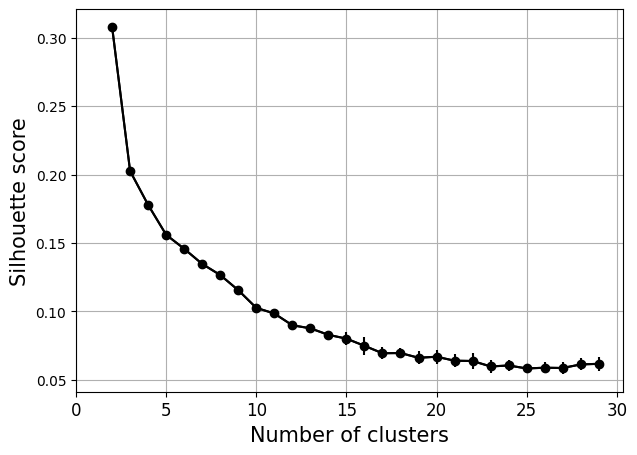

In [385]:
fig, ax = plt.subplots()
vba_tools.plot_silhouette_scores(silhouette_scores=silhouette_scores, silhouette_std=silhouette_std, 
                                 n_clusters=n_clusters, ax=ax);

ax.set_xlabel(ax.get_xlabel(), fontsize=15)
ax.set_ylabel(ax.get_ylabel(), fontsize=15)
ax.set_xticks(np.arange(0, k_max+1, 5))
ax.set_xticklabels(np.arange(0, k_max+1, 5), fontsize=12)
ax.set_title('')

In [ ]:
repeat_labels_nclusters = []
cocluster_mat_nclusters = []
ncluster_list = range(9,20)
n_boots = 1000
for n_clusters in ncluster_list:
    repeat_labels = []
    for _ in range(n_boots):
        model = SpectralClustering(n_clusters=n_clusters)
        model.fit_predict(feature_table.values)
        repeat_labels.append(order_cluster_ind_by_size(model.labels_))
    repeat_labels_nclusters.append(repeat_labels)
    num_cells = len(repeat_labels[0])
    cocluster_mat = np.zeros((num_cells, num_cells))
    for ri in range(n_boots):
        label = repeat_labels[ri]
        for ci in range(num_cells):
            cluster_label = label[ci]
            cocluster_cis = np.where(label==cluster_label)[0]
            cocluster_mat[ci, cocluster_cis] += 1
    cocluster_mat /= n_boots
    cocluster_mat_nclusters.append(cocluster_mat)

In [15]:
ray.shutdown()

In [13]:
cocluster_mat_nclusters = []
ncluster_list = range(9,20)
n_boots = 1000
vba_tools.initialize_ray()

t0 = time()
for n_clusters in ncluster_list:
    print(f'n_clusters: {n_clusters}')
    mat = vba_tools.get_coClust_matrix(feature_table,
                nboots=n_boots,
                n_clusters=n_clusters)
    cocluster_mat_nclusters.append(mat)
    t1 = time()
    print(f'Elapsed time: {(t1-t0)/60:.1f} min')
    t0 = t1
ray.shutdown()
# taks 1.2-1.3 minutes per cluster

2025-03-14 06:29:08,006	INFO worker.py:1672 -- Calling ray.init() again after it has already been called.


n_clusters: 9
(autoscaler +1h25m17s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
(autoscaler +1h25m52s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
Elapsed time: 1.2 min
n_clusters: 10
(autoscaler +1h26m27s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
(autoscaler +1h27m2s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer

NameError: name 'ray' is not defined

In [18]:
# save cocluster matrix
save_fn = glm_path / f'clustering/cocluster_{ncluster_list[0]}_{ncluster_list[-1]}_boot_{n_boots}.npy'
np.save(save_fn, cocluster_mat_nclusters)

In [11]:
# load cocluster matrix
load_fn = glm_path / f'clustering/cocluster_{ncluster_list[0]}_{ncluster_list[-1]}_boot_{n_boots}.npy'
cocluster_mat_nclusters = np.load(load_fn)

In [6]:
def order_cluster_ind_by_size(label):
    cluster_inds = np.unique(label)
    # sort by size and re-index
    cluster_size = np.array([np.sum(label==ci) for ci in cluster_inds])
    sorted_inds = np.argsort(-cluster_size)

    new_label = np.zeros(len(label), dtype=int) - 1
    for i in range(len(cluster_inds)):
        new_label[label==cluster_inds[sorted_inds[i]]] = i
    assert len(np.where(new_label==-1)[0]) == 0
    return new_label


def get_linkage_matrix_from_cocluster_matrix(cocluster_mat, method='ward'):
    distance_mat = 1 - cocluster_mat
    condensed_dist = squareform(distance_mat)
    linkage_matrix = sch.linkage(condensed_dist, method=method)
    return linkage_matrix


def draw_dendrogram_from_linkage_matrix(linkage_matrix, n_cluster, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    sch.dendrogram(linkage_matrix, ax=ax)
    ax.set_title(f"Hierarchical Clustering Dendrogram ({n_cluster} clusters)")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    return ax


def draw_coding_cluster_heatmap(linkage_matrix, n_cluster, feature_table, ax=None, show_colorbar=False,
aspect=0.05):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    index = feature_table.index.values
    # sorting feature_table index using leaf_order from the hierarchical clustering of co-clustering probability matrix
    cluster_labels = fcluster(linkage_matrix, n_cluster, criterion='maxclust')
    leaf_order = sch.leaves_list(linkage_matrix)
    sorted_index = index[leaf_order]

    # calculating borders
    cluster_inds = np.unique(cluster_labels)
    cluster_size = np.array([np.sum(cluster_labels==ci) for ci in cluster_inds])
    cluster_borders = np.cumsum(cluster_size)

    # Figure
    im = ax.imshow(-feature_table.loc[sorted_index, :].values, aspect=aspect, interpolation='none', cmap='Blues')

    # colorbar
    if show_colorbar:
        fig.subplots_adjust(right=0.65)
        cbar_ax = fig.add_axes([0.66, 0.25, 0.02, 0.5])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Coding score', fontsize=12)

    # borders
    for cluster_border in cluster_borders[:-1]:
        ax.axhline(cluster_border, color='k', linestyle='--')
    for x in [3,6,9]:
        ax.axvline(x-0.5, color='gray')

    # ticks, labels, titles
    ax.set_xticks(range(12))
    ax.set_xticklabels([' '.join(ftc) for ftc in list(feature_table.columns)],
                    rotation=90,
                    fontsize=12)
    yticks = np.array([0, *cluster_borders])
    ax.set_yticks(yticks)
    ax.set_ylabel('Inhibitory neurons', fontsize=12)
    ax.set_title(f'Num clusters={n_cluster}\n', fontsize=15)
    return ax


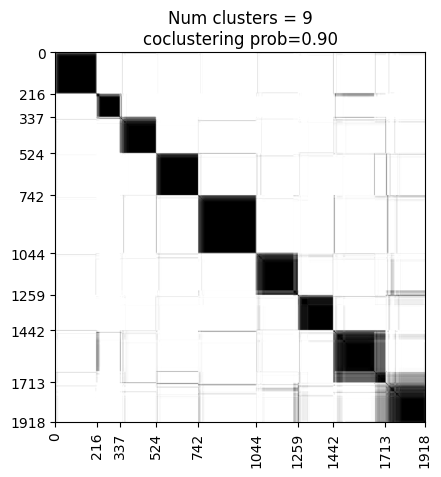

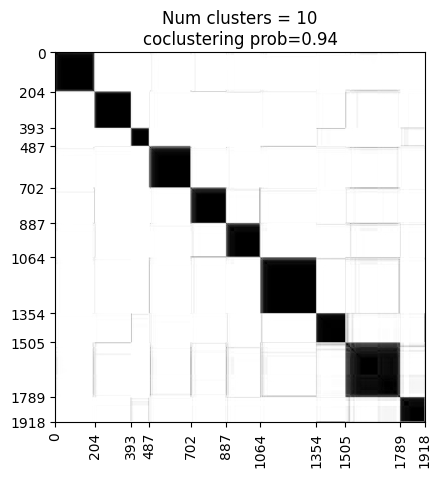

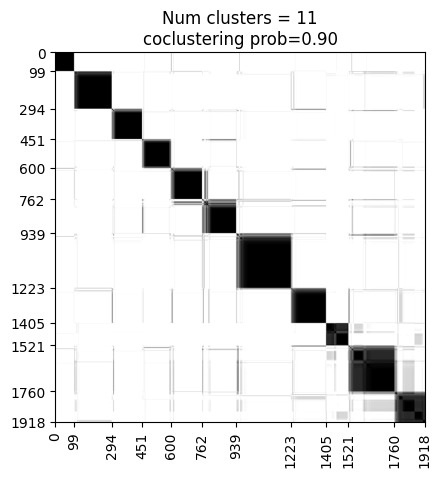

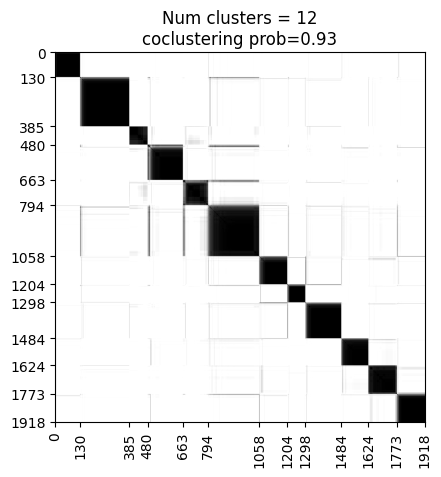

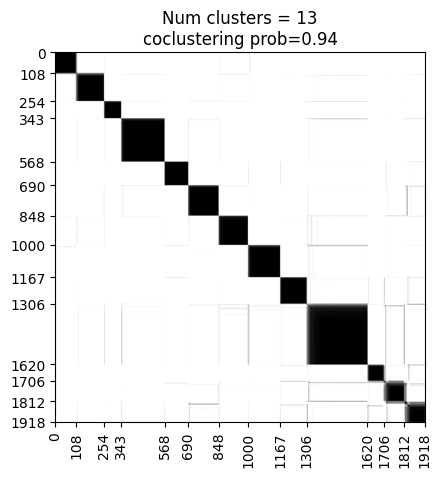

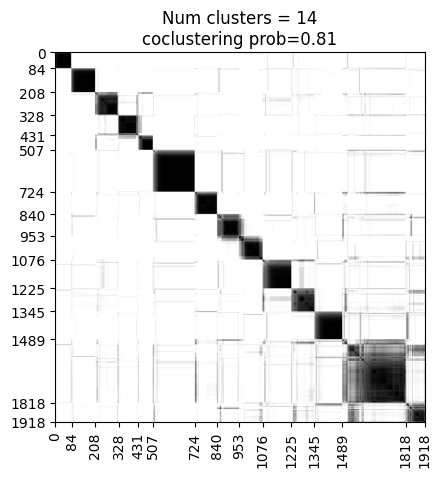

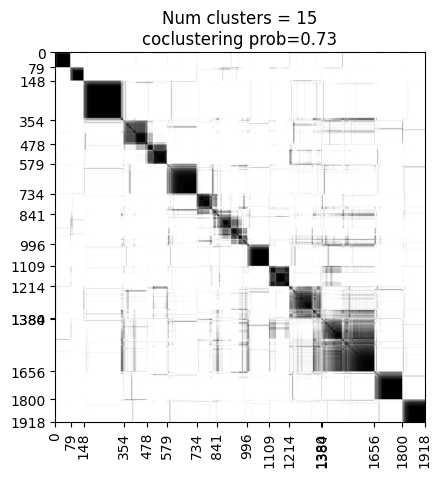

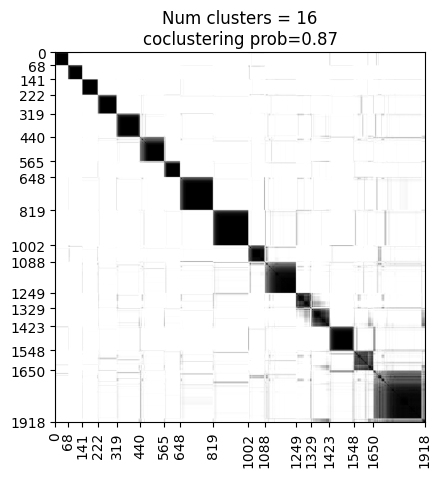

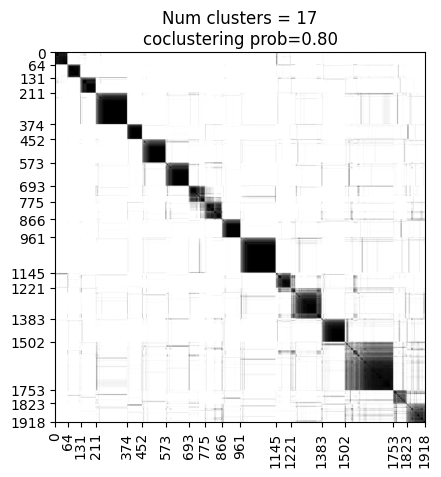

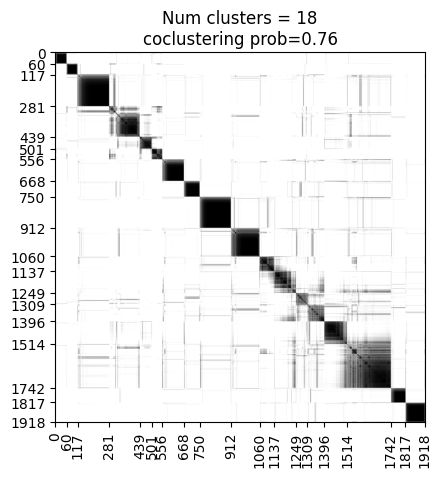

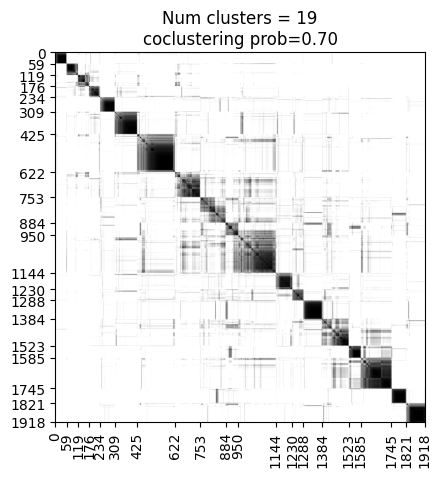

In [21]:
linkage_method = 'average'  # linkage method
# Compared with 'ward'. 'average' is better to capture transition between clusters ('neighborhoodness')
# Also 'average' uses probability values directly
mean_cc_prob_all = []
for cni, n_clusters in enumerate(ncluster_list):
    # re-order the cocluster matrix
    cocluster_mat = cocluster_mat_nclusters[cni]
    linkage_matrix = get_linkage_matrix_from_cocluster_matrix(cocluster_mat,
                                                              method=linkage_method)
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    leaf_order = sch.leaves_list(linkage_matrix)
    
    reordered_cocluster_mat = cocluster_mat[leaf_order, :][:, leaf_order]
    
    # calculate mean co-clustering probability
       
    # calculating borders
    cluster_inds = np.unique(cluster_labels)
    cluster_size = np.array([np.sum(cluster_labels==ci) for ci in cluster_inds])
    cluster_borders = np.array([0, *np.cumsum(cluster_size)])
    assert cluster_borders[-1] == len(cluster_labels)
    
    # within each cluster, calculate mean co-clustering (mean of the upper triangle)
    cc_prob = []
    for ci in range(n_clusters):
        row_inds = np.arange(cluster_borders[ci], cluster_borders[ci+1])
        cluster_mat = reordered_cocluster_mat[row_inds, :][:, row_inds]
        mean_cocluster_prop = np.mean(cluster_mat[np.triu_indices_from(cluster_mat, 1)])
        cc_prob.append(mean_cocluster_prop)
    mean_cc_prob = np.mean(cc_prob)
    mean_cc_prob_all.append(mean_cc_prob)
    
    fig, ax = plt.subplots()
    ax.imshow(reordered_cocluster_mat, cmap='gray_r')
    
    ax.set_title(f'Num clusters = {n_clusters}\ncoclustering prob={mean_cc_prob:.2f}')
    
    ax.set_xticks(cluster_borders)
    ax.tick_params(axis='x', rotation=90)
    ax.set_yticks(cluster_borders)
    

/tmp/ipykernel_3275/3329742013.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=15)
/tmp/ipykernel_3275/3329742013.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([round(y,2) for y in ax.get_yticks()], fontsize=15)


Text(0, 0.5, 'Mean co-clustering probability')

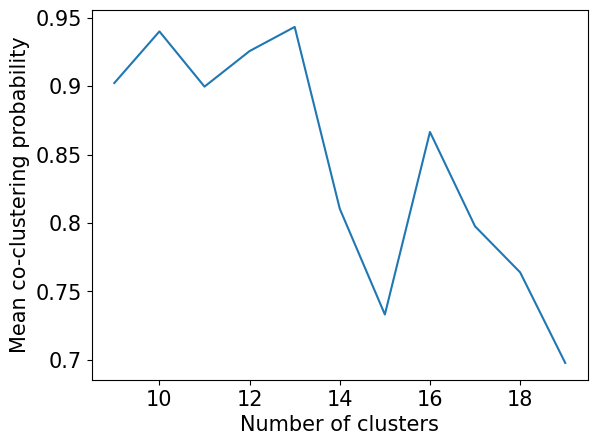

In [29]:
fig, ax = plt.subplots()
ax.plot(ncluster_list, mean_cc_prob_all)
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=15)
ax.set_yticklabels([round(y,2) for y in ax.get_yticks()], fontsize=15)
ax.set_xlabel('Number of clusters', fontsize=15)
ax.set_ylabel('Mean co-clustering probability', fontsize=15)

In [8]:
feature_table.columns

MultiIndex([(   'Images', 'Familiar'),
            (   'Images',    'Novel'),
            (   'Images',  'Novel+1'),
            ('Omissions', 'Familiar'),
            ('Omissions',    'Novel'),
            ('Omissions',  'Novel+1'),
            (     'Task', 'Familiar'),
            (     'Task',    'Novel'),
            (     'Task',  'Novel+1'),
            ( 'Behavior', 'Familiar'),
            ( 'Behavior',    'Novel'),
            ( 'Behavior',  'Novel+1')],
           names=['model', 'experience_level'])

In [12]:
cocluster_mat_nclusters

array([[[1.   , 0.029, 0.   , ..., 0.   , 0.   , 0.   ],
        [0.029, 1.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 1.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.   , 0.   , 0.   , ..., 1.   , 0.003, 0.003],
        [0.   , 0.   , 0.   , ..., 0.003, 1.   , 1.   ],
        [0.   , 0.   , 0.   , ..., 0.003, 1.   , 1.   ]],

       [[1.   , 0.398, 0.   , ..., 0.   , 0.   , 0.003],
        [0.398, 1.   , 0.   , ..., 0.   , 0.   , 0.037],
        [0.   , 0.   , 1.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.   , 0.   , 0.   , ..., 1.   , 0.037, 0.035],
        [0.   , 0.   , 0.   , ..., 0.037, 1.   , 0.945],
        [0.003, 0.037, 0.   , ..., 0.035, 0.945, 1.   ]],

       [[1.   , 0.197, 0.   , ..., 0.108, 0.   , 0.121],
        [0.197, 1.   , 0.   , ..., 0.001, 0.   , 0.002],
        [0.   , 0.   , 1.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.108, 0.001, 0.   , ..., 1.   , 0.003, 0.147],
        [0.   , 0.   , 0.   , ..., 0.003, 1. 

In [15]:
ncluster_list == n_cluster

False

Text(0, 0.5, 'Inhibitory neurons')

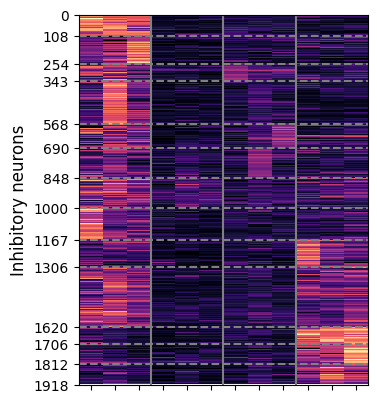

In [31]:
linkage_method = 'average' 
n_cluster = 13
ccind = np.where(np.array(ncluster_list) == n_cluster)[0][0]
cocluster_mat = cocluster_mat_nclusters[ccind]
linkage_matrix = get_linkage_matrix_from_cocluster_matrix(cocluster_mat,
                                                              method=linkage_method)
fig, ax = plt.subplots()
index = feature_table.index.values
# sorting feature_table index using leaf_order from the hierarchical clustering of co-clustering probability matrix
cluster_labels = fcluster(linkage_matrix, n_cluster, criterion='maxclust')
leaf_order = sch.leaves_list(linkage_matrix)
sorted_index = index[leaf_order]

# calculating borders
cluster_inds = np.unique(cluster_labels)
cluster_size = np.array([np.sum(cluster_labels==ci) for ci in cluster_inds])
cluster_borders = np.cumsum(cluster_size)

# Figure
im = ax.imshow(-feature_table.loc[sorted_index, :].values, aspect=0.008, interpolation='none', cmap='magma')

# borders
for cluster_border in cluster_borders[:-1]:
    ax.axhline(cluster_border, color='gray', linestyle='--')
for x in [3,6,9]:
    ax.axvline(x-0.5, color='gray')

# ticks, labels, titles
ax.set_xticks(range(12))
ax.set_xticklabels([])
# ax.set_xticklabels([' '.join(ftc) for ftc in list(feature_table.columns)],
#                 rotation=90,
#                 fontsize=12)
yticks = np.array([0, *cluster_borders])
ax.set_yticks(yticks)
ax.set_ylabel('Inhibitory neurons', fontsize=12)
# ax.set_title(f'Num clusters={n_cluster}\n', fontsize=15)

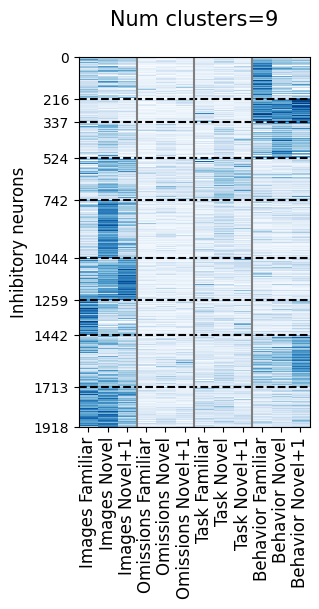

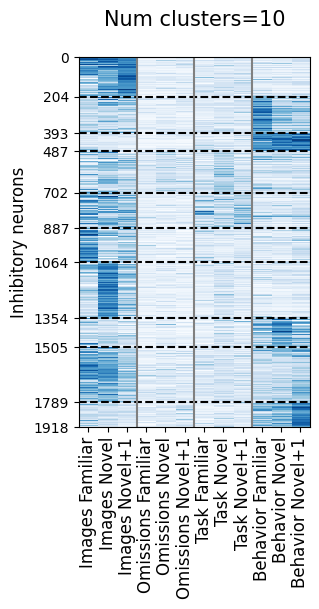

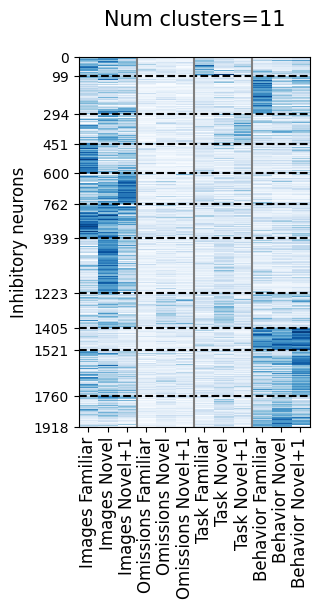

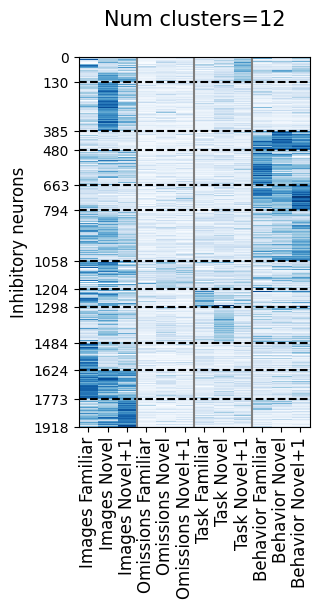

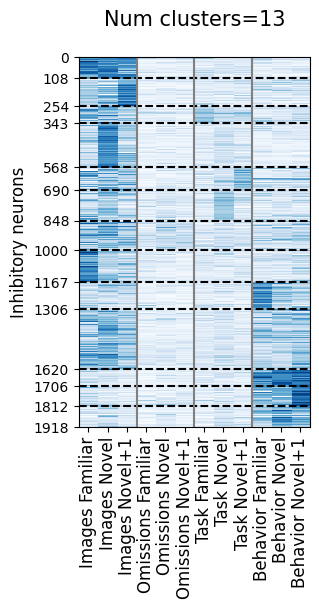

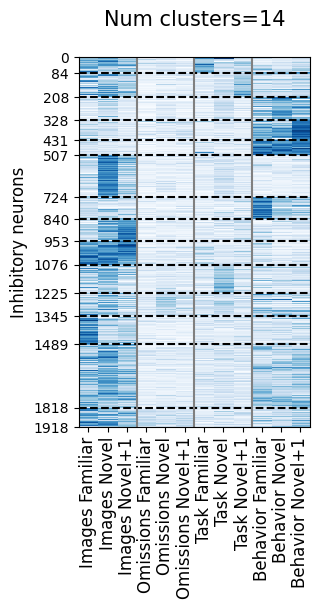

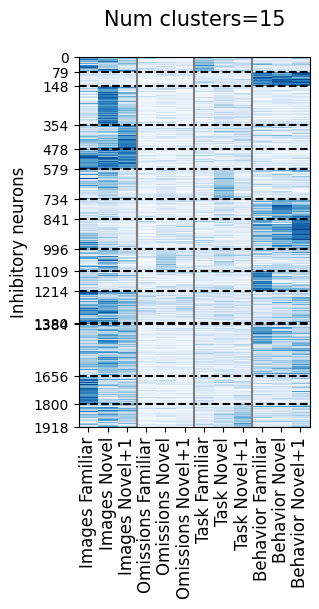

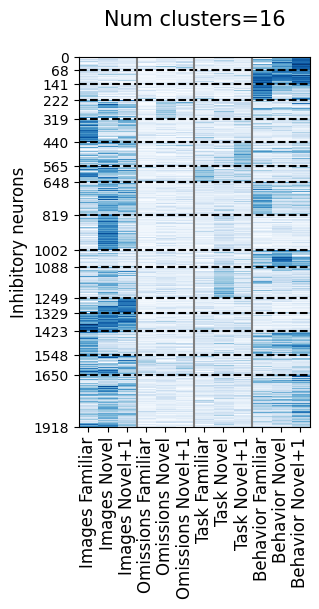

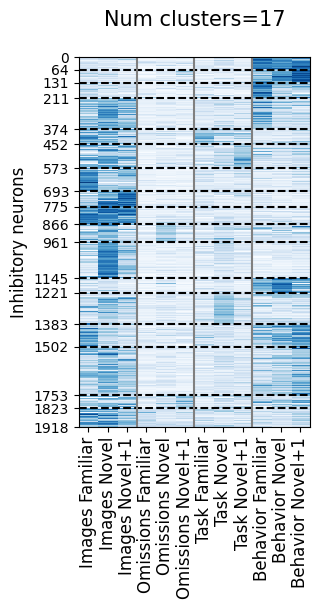

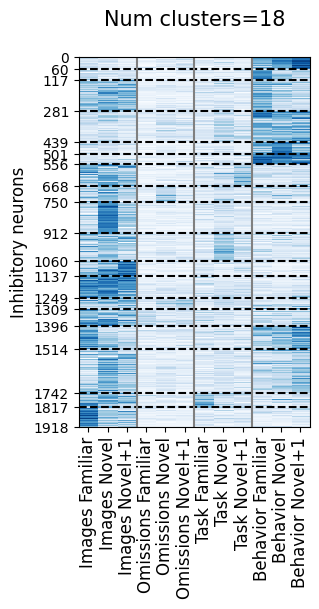

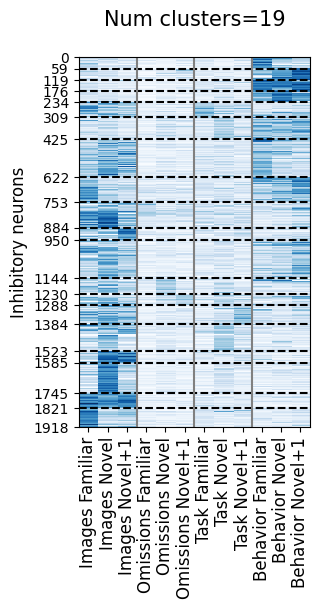

In [71]:
for ccind, n_cluster in enumerate(ncluster_list):
    cocluster_mat = cocluster_mat_nclusters[ccind]
    linkage_matrix = get_linkage_matrix_from_cocluster_matrix(cocluster_mat, method=linkage_method)
    # fig, ax = plt.subplots(figsize=(10, 5))
    # ax = draw_dendrogram_from_linkage_matrix(linkage_matrix, n_cluster, ax=ax)
    
    ax = draw_coding_cluster_heatmap(linkage_matrix, n_cluster, feature_table,
                                        aspect=0.01)


### Dev work

In [120]:
mouse_id = 721291
# ValueError: cannot reindex or align along dimension 'unique_cell_name' because the (pandas) index has duplicate values


721291

In [141]:
version=3
data_type='events'
glm_path=Path('/root/capsule/scratch/glm/')

# get roicat_df
roicat_df_fn = glm_path / f'roicat_df_{mouse_id}.pkl'
if not os.path.exists(roicat_df_fn):
    raise ValueError(f'ROICaT results not found for {mouse_id}')
roicat_df = pd.read_pickle(roicat_df_fn)

# get session_info_df
session_info_df = cdu.get_session_info(mouse_id)

# focus on FNN sessions only
fnn_session_keys = cu.get_fnn_session_keys(session_info_df)
fnn_all_matched_roi_df = cu.get_fnn_all_matched_roi_df(fnn_session_keys, roicat_df)

In [126]:
include_models=['all-images', 'omissions', 'task', 'behavioral']
filter_threshold=0.005

coding_score_table = fnn_all_matched_roi_df.reset_index()[['roi_name',
                                            'unique_cell_name', 'session_ind',
                                            'session_key', 'fov_name',
                                            'roi_session_index']].copy()
session_keys = np.sort(coding_score_table.session_key.unique())

coding_score_raw = None
for session_key in session_keys:
    session_matched_roi_name = ['_'.join(rn.split('_')[-3:]) for rn in \
        fnn_all_matched_roi_df.query(f'session_key=="{session_key}"').index.values]
    
    # session_name = session_info_df.loc[session_key, 'session_name']
    # session_ind = session_info_df.loc[session_key, 'session_ind']
    coding_score_fn = glm_path / f'{session_key}_glm_v{dm_version:02}/\
coding_score_v{dm_version:02}_{session_key}_{data_type}{suffix}.nc'
    with xr.open_dataarray(coding_score_fn) as ds:
        coding_score_session = ds.expand_dims(
                                'session').assign_coords(
                                    session=[session_key])
        cell_roi_ids = coding_score_session.cell_roi_id.values
        
        # get filtered cell_roi_ids during glm fitting (<1% active frames)
        X, activity_trace, activity_trace_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_key, data_type, dm_version, load_path=glm_path)
        activity_trace_trim = activity_trace[use_indices, :]
        activity_trace_trim_filtered = gft.filter_activity_trace_matrix(activity_trace_trim)
        filtered_cell_roi_id = np.setdiff1d(activity_trace_trim.cell_roi_id.values,
                                activity_trace_trim_filtered.cell_roi_id.values)
        
        # if there are missing cell_roi_ids among filtered cell_roi_ids,
        # add them to coding_score_session and fill with 0
        missing_cell_roi_ids = np.setdiff1d(filtered_cell_roi_id, cell_roi_ids)
        if len(missing_cell_roi_ids) > 0:
            new_cell_roi_ids = np.concatenate([cell_roi_ids, missing_cell_roi_ids])
            coding_score_session = coding_score_session.reindex(
                                    cell_roi_id=new_cell_roi_ids, fill_value=0)
        
        # Choose only the matched cell_roi_ids
        # Also only from models of interest
        coding_score_session = coding_score_session.sel(
                                cell_roi_id=session_matched_roi_name,
                                model=include_models).copy()
        
        # Swap cell_roi_id which is session-specific to unique_cell_name
        # for concatenation across sessions
        unique_cell_names = []
        for cell_roi_id in coding_score_session.cell_roi_id.values:
            roi_name = f'{session_key}_{cell_roi_id}'
            unique_cell_names.append(fnn_all_matched_roi_df.loc[
                                roi_name, 'unique_cell_name'])

        coding_score_session = coding_score_session.assign_coords(
                                unique_cell_name=(
                                    "cell_roi_id", unique_cell_names))
        coding_score_session = coding_score_session.swap_dims(
                                {"cell_roi_id": "unique_cell_name"})
        coding_score_session = coding_score_session.reset_coords(
                                'cell_roi_id', drop=True)
    if coding_score_raw is None:
        coding_score_raw = coding_score_session
    else:
        coding_score_raw = xr.concat([coding_score_raw, coding_score_session],
                        dim='session')

ValueError: cannot reindex or align along dimension 'unique_cell_name' because the (pandas) index has duplicate values

In [130]:
coding_score_raw

<xarray.DataArray 'coding_score_metrics_from_session_model' (session: 1,
                                                             metric: 3,
                                                             model: 4,
                                                             unique_cell_name: 322)> Size: 31kB
array([[[[ 0.02862374,  0.02255118,  0.01790712, ...,  0.01061189,
           0.03805439,  0.03596589],
         [ 0.08437651,  0.03920284,  0.03473188, ...,  0.02160304,
           0.0604776 ,  0.09425389],
         [ 0.04942562,  0.01075136,  0.02857047, ...,  0.0279243 ,
           0.04596134,  0.09616643],
         [ 0.04683832,  0.01736984,  0.0231899 , ...,  0.01238004,
           0.03400412,  0.07627298]],

        [[ 0.06481888,  0.03628208,  0.03555837, ...,  0.02009137,
           0.06219474,  0.08942962],
         [ 0.08876917,  0.04230288,  0.04121099, ...,  0.02787745,
           0.07178351,  0.10588244],
         [ 0.06709884,  0.01896433,  0.0379102 , ...,  0.03311589,
           0.06139705,  0.14218105],
         [ 0.06749704,  0.03564358,  0.03530513, ...,  0.01989616,
           0.06108791,  0.08978856]],

        [[-0.55840433, -0.37844844, -0.49640208, ..., -0.47181843,
          -0.38814141, -0.59783016],
         [-0.04948412, -0.07328206, -0.15721801, ..., -0.22507113,
          -0.15750009, -0.10982514],
         [-0.26339077, -0.43307444, -0.24636449, ..., -0.15677035,
          -0.25140803, -0.32363394],
         [-0.30606848, -0.51267967, -0.34315789, ..., -0.37776749,
          -0.4433576 , -0.15052678]]]])
Coordinates:
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * metric            (metric) object 24B 'adj_ve_model' ... 'coding_score'
  * session           (session) <U17 68B '721291_2024-05-13'
  * unique_cell_name  (unique_cell_name) <U11 14kB 'VISp_0_0101' ... 'VISp_7_...

In [129]:
coding_score_session

<xarray.DataArray 'coding_score_metrics_from_session_model' (session: 1,
                                                             metric: 3,
                                                             model: 4,
                                                             unique_cell_name: 320)> Size: 31kB
array([[[[ 0.01904123,  0.03344178,  0.04939773, ...,  0.01662276,
           0.05666593,  0.06811198],
         [ 0.03044447,  0.09338962,  0.07857282, ...,  0.02054149,
           0.081656  ,  0.18515923],
         [ 0.02877985,  0.05423585,  0.07749938, ...,  0.04128963,
           0.09956268,  0.16873145],
         [ 0.02008153,  0.06855311,  0.07496405, ...,  0.02296126,
           0.04919045,  0.16008145]],

        [[ 0.03650683,  0.08244951,  0.09021428, ...,  0.03136965,
           0.08003272,  0.17188087],
         [ 0.03314727,  0.10619821,  0.10162025, ...,  0.02380969,
           0.09028082,  0.19313719],
         [ 0.03428674,  0.07131134,  0.09839151, ...,  0.04996749,
           0.12022736,  0.21316907],
         [ 0.0355746 ,  0.08750012,  0.08827118, ...,  0.02984512,
           0.07918727,  0.17306631]],

        [[-0.47842009, -0.59439681, -0.45244009, ..., -0.47010044,
          -0.29196555, -0.60372567],
         [-0.08153899, -0.12061029, -0.22679956, ..., -0.13726357,
          -0.09553321, -0.0413072 ],
         [-0.1606128 , -0.23944985, -0.2123368 , ..., -0.1736701 ,
          -0.17188   , -0.20846189],
         [-0.43550938, -0.21653694, -0.15075285, ..., -0.23065287,
          -0.3788086 , -0.07502823]]]])
Coordinates:
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * metric            (metric) object 24B 'adj_ve_model' ... 'coding_score'
  * session           (session) <U17 68B '721291_2024-05-14'
  * unique_cell_name  (unique_cell_name) <U11 14kB 'VISp_0_0119' ... 'VISp_7_...

In [128]:
session_keys

array(['721291_2024-05-13', '721291_2024-05-14', '721291_2024-05-16'],
      dtype=object)

In [127]:
session_key

'721291_2024-05-14'

In [70]:
mouse_id = mouse_ids[0]
version=3
data_type='events'
glm_path=Path('/root/capsule/scratch/glm/')
if isinstance(glm_path, str):
    glm_path = Path(glm_path)
# get roicat_df
roicat_df_fn = glm_path / f'roicat_df_{mouse_id}.pkl'
if not os.path.exists(roicat_df_fn):
    raise ValueError(f'ROICaT results not found for {mouse_id}')
roicat_df = pd.read_pickle(roicat_df_fn)

# get session_info_df
session_info_df = cdu.get_session_info(mouse_id)

# focus on FNN sessions only
fnn_session_keys = cu.get_fnn_session_keys(session_info_df)
fnn_all_matched_roi_df = cu.get_fnn_all_matched_roi_df(fnn_session_keys, roicat_df)

cs_norm = cs.cross_session_normalization(fnn_all_matched_roi_df, session_info_df)
save_fn = glm_path / f'coding_score_fnn_normalized_v{version:02}_{mouse_id}_{data_type}.nc'

In [113]:
if os.path.exists(save_fn):
    os.remove(save_fn)
import xarray as xr
# new_arr = xr.DataArray(
#     data=cs_norm.values,
#     dims=cs_norm.dims,
#     coords={dim: range(len(cs_norm[dim])) for dim in cs_norm.dims}
# )
new_arr.to_netcdf(save_fn)

In [114]:
print("Dimensions:", cs_norm.dims)
print("Coordinates:")
for name, coord in cs_norm.coords.items():
    print(f"- {name}: shape {coord.shape}")

Dimensions: ('session', 'model', 'unique_cell_name')
Coordinates:
- model: shape (4,)
- unique_cell_name: shape (397,)
- session: shape (3,)


In [116]:
new_arr.equals(cs_norm)

True

In [111]:
import xarray as xr

# First, extract your original data and coordinate values
data = cs_norm.values

# Create a new dataarray with correct dimensions but carefully transfer coordinates
new_arr = xr.DataArray(
    data=data,
    dims=cs_norm.dims
)

# Add coordinates one by one, checking each for consistency
for dim in cs_norm.dims:
    # Get original coordinate values for this dimension
    try:
        # This gets the 1D coordinate values along the dimension
        coord_values = cs_norm.coords[dim].values
        
        # Verify length matches the corresponding dimension in data
        expected_length = data.shape[cs_norm.dims.index(dim)]
        if len(coord_values) == expected_length:
            new_arr.coords[dim] = coord_values
        else:
            print(f"Warning: Coordinate '{dim}' has length {len(coord_values)} but dimension has length {expected_length}")
            # Use default indices instead
            new_arr.coords[dim] = range(expected_length)
    except KeyError:
        # If dimension doesn't have a coordinate with same name
        print(f"Note: Creating default coordinate for dimension '{dim}'")
        new_arr.coords[dim] = range(data.shape[cs_norm.dims.index(dim)])

# Now add any non-dimension coordinates
for coord_name in cs_norm.coords:
    if coord_name not in cs_norm.dims:
        try:
            # Check shape compatibility
            if all(dim in new_arr.dims for dim in cs_norm[coord_name].dims):
                # Verify sizes match
                sizes_match = True
                for dim in cs_norm[coord_name].dims:
                    if len(cs_norm[coord_name][dim]) != len(new_arr[dim]):
                        sizes_match = False
                        print(f"Warning: Non-dimension coordinate '{coord_name}' has incompatible shape")
                        break
                
                if sizes_match:
                    new_arr.coords[coord_name] = cs_norm.coords[coord_name]
        except Exception as e:
            print(f"Skipping coordinate '{coord_name}': {str(e)}")

# Add any attributes
new_arr.attrs = cs_norm.attrs

# Try saving now
# new_arr.to_netcdf('fixed_with_coords.nc')

In [117]:
cs_norm

<xarray.DataArray 'coding_score_metrics_from_session_model' (session: 3,
                                                             model: 4,
                                                             unique_cell_name: 397)> Size: 38kB
array([[[-0.161331  , -0.10310965, -0.19801683, ..., -0.26308501,
         -0.41763629, -0.30107509],
        [-0.08609297, -0.10034825, -0.03674671, ..., -0.05366602,
         -0.11166723, -0.05860476],
        [-0.14613435, -0.02932348, -0.07323247, ..., -0.24979875,
         -0.12662123, -0.10008964],
        [-0.2541216 , -0.21996798, -0.71892114, ..., -0.53144046,
         -0.46467742, -0.65984948]],

       [[-0.14637982, -0.15160839, -0.20471443, ..., -0.10812428,
         -0.10229125, -0.05163173],
        [-0.10206384, -0.1094414 , -0.10979805, ..., -0.2404673 ,
         -0.04776465, -0.02158409],
        [-0.22968534, -0.29784985, -0.15832127, ..., -0.26702187,
         -0.0283404 , -0.03794201],
        [-0.42487541, -0.34455422, -0.59398132, ..., -0.3404857 ,
         -0.17030788, -0.33850226]],

       [[-0.12958936, -0.0861634 , -0.10831015, ..., -0.2092541 ,
         -0.17400986, -0.12192966],
        [-0.10915491, -0.12363923, -0.14813195, ..., -0.16202868,
         -0.16157661, -0.05694905],
        [-0.05344009, -0.05116524, -0.13296944, ..., -0.0848034 ,
         -0.13367107, -0.13364374],
        [-0.63070996, -0.49348349, -0.75696495, ..., -0.23190951,
         -0.31937999, -0.36214756]]])
Coordinates:
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * unique_cell_name  (unique_cell_name) <U11 17kB 'VISp_0_0006' ... 'VISp_7_...
  * session           (session) <U17 204B '717824_2024-04-24' ... '717824_202...

In [112]:
new_arr

<xarray.DataArray (session: 3, model: 4, unique_cell_name: 397)> Size: 38kB
array([[[-0.161331  , -0.10310965, -0.19801683, ..., -0.26308501,
         -0.41763629, -0.30107509],
        [-0.08609297, -0.10034825, -0.03674671, ..., -0.05366602,
         -0.11166723, -0.05860476],
        [-0.14613435, -0.02932348, -0.07323247, ..., -0.24979875,
         -0.12662123, -0.10008964],
        [-0.2541216 , -0.21996798, -0.71892114, ..., -0.53144046,
         -0.46467742, -0.65984948]],

       [[-0.14637982, -0.15160839, -0.20471443, ..., -0.10812428,
         -0.10229125, -0.05163173],
        [-0.10206384, -0.1094414 , -0.10979805, ..., -0.2404673 ,
         -0.04776465, -0.02158409],
        [-0.22968534, -0.29784985, -0.15832127, ..., -0.26702187,
         -0.0283404 , -0.03794201],
        [-0.42487541, -0.34455422, -0.59398132, ..., -0.3404857 ,
         -0.17030788, -0.33850226]],

       [[-0.12958936, -0.0861634 , -0.10831015, ..., -0.2092541 ,
         -0.17400986, -0.12192966],
        [-0.10915491, -0.12363923, -0.14813195, ..., -0.16202868,
         -0.16157661, -0.05694905],
        [-0.05344009, -0.05116524, -0.13296944, ..., -0.0848034 ,
         -0.13367107, -0.13364374],
        [-0.63070996, -0.49348349, -0.75696495, ..., -0.23190951,
         -0.31937999, -0.36214756]]])
Coordinates:
  * session           (session) <U17 204B '717824_2024-04-24' ... '717824_202...
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * unique_cell_name  (unique_cell_name) <U11 17kB 'VISp_0_0006' ... 'VISp_7_...

In [118]:
# Check if there are encoding differences
print("cs_norm encoding:", cs_norm.encoding)
print("new_arr encoding:", new_arr.encoding)

# Check the internal structure more carefully
print("cs_norm internal:", cs_norm._to_temp_dataset())
print("new_arr internal:", new_arr._to_temp_dataset())

# Check data types
for coord in cs_norm.coords:
    print(f"Coord {coord} types - original: {cs_norm[coord].dtype}, new: {new_arr[coord].dtype}")

cs_norm encoding: {}
new_arr encoding: {}
cs_norm internal: <xarray.Dataset> Size: 56kB
Dimensions:           (model: 4, unique_cell_name: 397, session: 3)
Coordinates:
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * unique_cell_name  (unique_cell_name) <U11 17kB 'VISp_0_0006' ... 'VISp_7_...
  * session           (session) <U17 204B '717824_2024-04-24' ... '717824_202...
Data variables:
    <this-array>      (session, model, unique_cell_name) float64 38kB -0.1613...
new_arr internal: <xarray.Dataset> Size: 56kB
Dimensions:           (session: 3, model: 4, unique_cell_name: 397)
Coordinates:
  * session           (session) <U17 204B '717824_2024-04-24' ... '717824_202...
  * model             (model) object 32B 'all-images' ... 'behavioral'
  * unique_cell_name  (unique_cell_name) <U11 17kB 'VISp_0_0006' ... 'VISp_7_...
Data variables:
    <this-array>      (session, model, unique_cell_name) float64 38kB -0.1613...
Coord model types - original: object, new: o

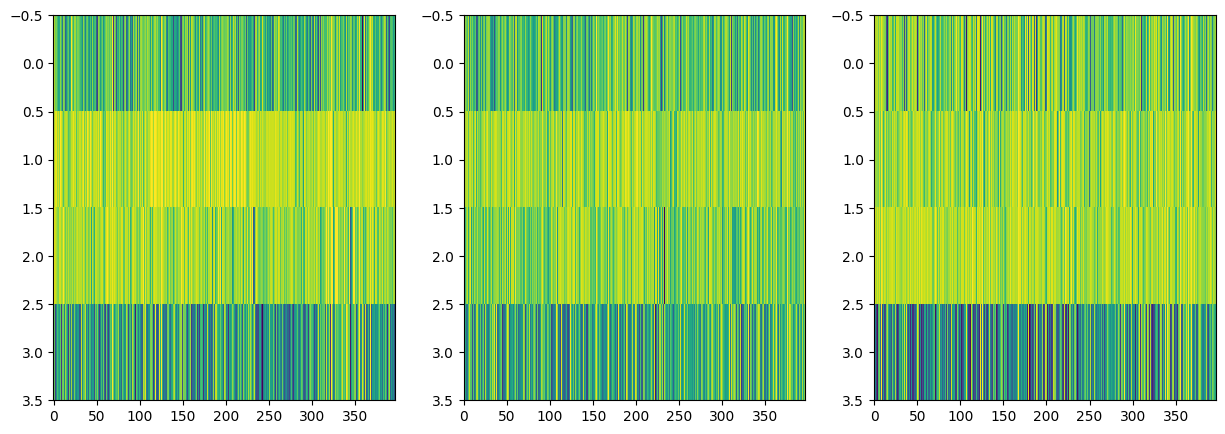

In [105]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(1,3, figsize=(15,5))
for si in range(3):
    ax[si].imshow(cs_norm.values[si,:,:], aspect='auto', cmap='viridis', interpolation='none')

In [107]:
cs_norm.model.values

array(['all-images', 'omissions', 'task', 'behavioral'], dtype=object)

In [97]:
os.path.exists(save_fn)

True

In [96]:
cs_norm.encoding = {} 
cs_norm.to_netcdf(save_fn)

ValueError: could not broadcast input array from shape (4,10) into shape (4,17)

In [89]:
os.path.exists(save_fn)

True

In [88]:
cs_norm.to_dataset(name="cs_norm").to_netcdf(save_fn)
# cs_norm.to_netcdf(save_fn)

ValueError: could not broadcast input array from shape (4,10) into shape (4,17)

In [26]:
mouse = mouse_ids[0]
roicat_df_fn = glm_path / f'roicat_df_{mouse}.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)

session_info_df = cdu.get_session_info(mouse)

In [33]:
fnn_session_inds = []
potential_f_sessions = session_info_df.query('session_type == "OPHYS_1_images_A"')
if len(potential_f_sessions) == 0:
    raise ValueError('No Familiar sessions found')
fnn_session_inds.append(potential_f_sessions.session_ind.min())

potential_n_sessions = session_info_df.query('session_type == "OPHYS_4_images_B"')
if len(potential_n_sessions) == 0:
    raise ValueError('No Novel sessions found')
elif len(potential_n_sessions) == 1:
    raise ValueError('Only one Novel session found')
elif len(potential_n_sessions) > 2:
    raise ValueError('More than two Novel sessions found')
for si in potential_n_sessions.session_ind.values:
    fnn_session_inds.append(si)


In [36]:
fnn_roi_df = roicat_df.query('session_ind in @fnn_session_inds and valid_roi')
fnn_uc_series = fnn_roi_df.groupby('unique_cell_name').size()
fnn_matched_uc = fnn_uc_series.index.values[np.where(fnn_uc_series==len(fnn_session_inds))[0]]
print(len(fnn_matched_uc))
fnn_all_matched_roi_df = fnn_roi_df.query('unique_cell_name in @fnn_matched_uc')
assert fnn_all_matched_roi_df.valid_roi.all()
fnn_all_matched_roi_df.head()

397


,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,session_ind,unique_cell_name,cell_roi_id,touching_motion_border,small_roi,valid_roi,exclusion_labels,plane_session_key
roi_name,,,,,,,,,,,,,,,,,,
717824_2024-04-24_VISp_0_0014,14,VISp_0,multiplane-ophys_717824_2024-04-24_09-20-18_pr...,14,6,376f6dc5-368e-4618-b607-fe1ee4e55a4f,0.890073,NaN,True,717824_2024-04-24,0,VISp_0_0006,14,False,False,True,None,717824_2024-04-24_VISp_0
717824_2024-04-24_VISp_0_0016,16,VISp_0,multiplane-ophys_717824_2024-04-24_09-20-18_pr...,16,7,99e0e882-0e34-42a5-b300-854510ae40a6,0.987387,NaN,True,717824_2024-04-24,0,VISp_0_0007,16,False,False,True,None,717824_2024-04-24_VISp_0
717824_2024-04-24_VISp_0_0018,18,VISp_0,multiplane-ophys_717824_2024-04-24_09-20-18_pr...,18,9,145c10eb-53b0-4b28-bf87-c29356d035a4,0.871626,NaN,True,717824_2024-04-24,0,VISp_0_0009,18,False,False,True,None,717824_2024-04-24_VISp_0
717824_2024-04-24_VISp_0_0019,19,VISp_0,multiplane-ophys_717824_2024-04-24_09-20-18_pr...,19,10,87f321c2-50c1-460e-840f-4362bf9b229c,0.831163,NaN,True,717824_2024-04-24,0,VISp_0_0010,19,False,False,True,None,717824_2024-04-24_VISp_0
717824_2024-04-24_VISp_0_0020,20,VISp_0,multiplane-ophys_717824_2024-04-24_09-20-18_pr...,20,11,49a512bc-8a4e-474b-ae44-8cde0fc6da48,0.986439,NaN,True,717824_2024-04-24,0,VISp_0_0011,20,False,False,True,None,717824_2024-04-24_VISp_0


In [63]:
cs_norm = cs.cross_session_normalization(fnn_all_matched_roi_df, session_info_df)